> **Purpose:** empirically verify Prop. (HBM spectral-gap bound) — `prop:D-gap`.
> **Data:** synthesized (HBM similarity matrices)

# HBM Spectral-Gap Verification

Empirical verification of the **HBM spectral-gap bound** (`prop:D-gap`) on simulated
hierarchical block-model similarity matrices.

The HBM relaxes the flat CBM by letting intra-clan similarities decay geometrically
with tree depth:
$$
S_{ij} = S_{\text{in}}\,\alpha^{\,d(i,j)}\quad\text{(same clan)},\qquad
S_{ij} = S_{\text{out}}^{\max}\quad\text{(cross clan)},
$$
where $d(i,j)$ is the merge-depth of the smallest common subtree under a recursive
near-equal binary split. The weakest intra-clan similarity is bounded by the
**geometric floor**
$$
S_{\text{in}}^{\min} \;\ge\; S_{\text{in}}\,\alpha^{D_{\max}},
\qquad D_{\max} = \big\lceil \log_2 \max(n_1,n_2) \big\rceil .
$$
Substituting the floor into the CBM gap lemma (`lem:A-gap`) gives the bound
$$
\Delta\lambda \;=\; \lambda_3-\lambda_2
\;\ge\; m_{\min}\,S_{\text{in}}\,\alpha^{D_{\max}}
       -(1+\eta)\,m_{\min}\,S_{\text{out}}^{\max}
\;=:\; \Delta\lambda_{\text{bound}},
$$
positive iff $\alpha^{D_{\max}} > (1+\eta)\,S_{\text{out}}^{\max}/S_{\text{in}}$, with
$m_{\min}=\min(n_1,n_2)$ and imbalance $\eta = \max(n_1,n_2)/m_{\min}$.

**What we verify:** the *slack* $\Delta\lambda - \Delta\lambda_{\text{bound}}$ stays
$\ge 0$ across the whole $(\eta, \alpha)$ sweep — the bound is a valid lower bound
even where it turns negative (no positive gap is guaranteed) at large $\eta$ / small
$\alpha$.

**Two panels (saved as `S_by_alpha.png`, `spectral_gap_bound.png`):**
- **Left:** the HBM similarity matrix $S$ degrading as $\alpha$ decreases.
- **Right:** slack of the gap lower bound versus $\eta$, one curve per decay rate.

## Cell 1 — Configuration & imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd()
while ROOT.parent != ROOT and not (ROOT / "setup.py").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT / "sub_sampled_fielder_vec"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis.utils import (
    build_decay_cbm_S, imbalance_eta, hbm_d_max,
)
from src.core.utils import compute_laplacian

# --- HBM parameters (match the flat-CBM notebook) ---
S_IN        = 0.9      # top-level intra-clan baseline
S_OUT       = 0.05     # constant cross-clan similarity  (S_out^max)
ALPHAS      = [1.00, 0.99, 0.95, 0.90]   # per-edge geometric decay rates

# Left panel: one representative matrix per alpha at a fixed, visibly-imbalanced (n1, n2).
M_SHOW      = 128
ETA_SHOW    = 3                       # n1 : n2 = 1 : 3
N1_SHOW     = max(1, round(M_SHOW / (1 + ETA_SHOW)))
N2_SHOW     = M_SHOW - N1_SHOW

# Right panel: sweep eta at fixed total size m, one curve per alpha.
M_SWEEP     = 512
ETA_GRID    = [1, 1.5, 2, 3, 4, 6, 8, 12, 16]

# Both S_by_alpha.png (Cell 2) and spectral_gap_bound.png (Cell 4) are written from
# this single OUT_DIR so the two panels of the paper figure come from one run.
OUT_DIR = PROJECT_ROOT / "docs" / "overleafs" / "v9" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Semantic palette: gray (alpha=1, the CBM limit) -> blue -> orange -> red (strongest decay).
ALPHA_COLORS = {1.00: "#6b7280", 0.99: "#1d4ed8", 0.95: "#ea580c", 0.90: "#b91c1c"}
print(f"left panel: n1={N1_SHOW}, n2={N2_SHOW} (eta={imbalance_eta(N1_SHOW, N2_SHOW):.0f})")
print(f"right panel: m={M_SWEEP}, eta grid={ETA_GRID}")
print(f"out_dir={OUT_DIR}")


left panel: n1=32, n2=96 (eta=3)
right panel: m=512, eta grid=[1, 1.5, 2, 3, 4, 6, 8, 12, 16]
out_dir=/Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/docs/overleafs/v9/figures


## Cell 2 — Left panel: `S_by_alpha.png`

The HBM similarity matrix at fixed $(n_1,n_2)$ for each decay rate. At $\alpha=1.0$
every intra-clan entry equals $S_{\text{in}}$ (flat CBM, two solid diagonal blocks);
as $\alpha$ falls the diagonal blocks develop the nested-block staircase of
geometric decay, driving the weakest intra-clan entry down toward
$S_{\text{in}}\alpha^{D_{\max}}$.

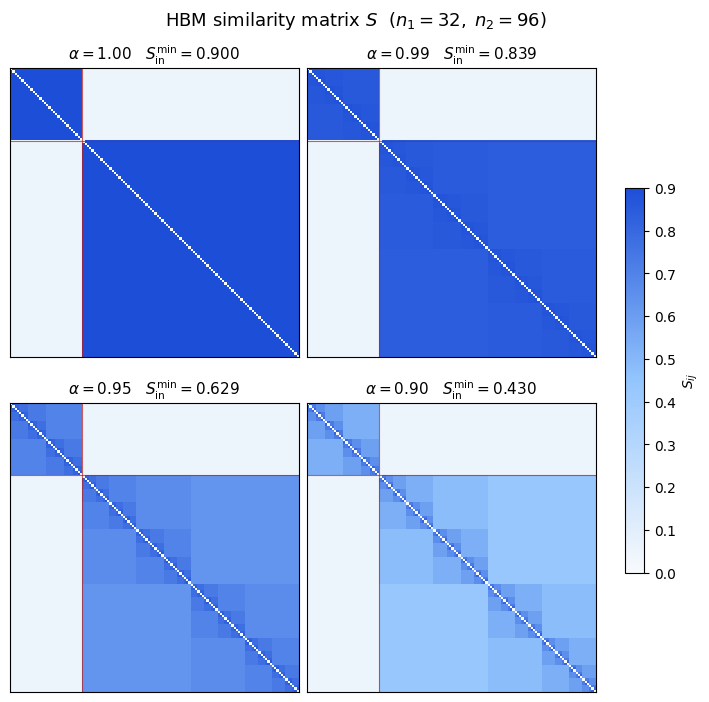

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(7, 7), constrained_layout=True)

# Sequential gray->blue colormap; vmax fixed at S_IN so blocks are comparable across alpha.
sim_cmap = LinearSegmentedColormap.from_list("sim", ["#f8fafc", "#93c5fd", "#1d4ed8"])

im = None
for ax, alpha in zip(axes.ravel(), ALPHAS):
    S = build_decay_cbm_S(N1_SHOW, N2_SHOW, S_IN, S_OUT, alpha=alpha)
    im = ax.imshow(S, cmap=sim_cmap, vmin=0.0, vmax=S_IN, interpolation="nearest")
    dmax = hbm_d_max(max(N1_SHOW, N2_SHOW))
    s_in_min = S_IN * alpha ** dmax
    ax.set_title(rf"$\alpha={alpha:.2f}$   "
                 rf"$S_{{\rm in}}^{{\min}}={s_in_min:.3f}$", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    # mark the clan boundary
    ax.axhline(N1_SHOW - 0.5, color="#b91c1c", lw=0.8, alpha=0.7)
    ax.axvline(N1_SHOW - 0.5, color="#b91c1c", lw=0.8, alpha=0.7)

fig.colorbar(im, ax=axes, shrink=0.6, label=r"$S_{ij}$", location="right")
fig.suptitle(rf"HBM similarity matrix $S$  ($n_1={N1_SHOW},\; n_2={N2_SHOW}$)",
             fontsize=13)
fig.savefig(OUT_DIR / "S_by_alpha.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 3 — Compute the sweep

For each $(\eta,\alpha)$: build the HBM matrix at total size $m=$`M_SWEEP`, form
$L=D-S$, read off $\lambda_2,\lambda_3$, and compare the **empirical gap**
$\Delta\lambda=\lambda_3-\lambda_2$ to the analytic bound
$\Delta\lambda_{\text{bound}}=m_{\min}S_{\text{in}}\alpha^{D_{\max}}-(1+\eta)m_{\min}S_{\text{out}}^{\max}$.

In [3]:
def gap_and_bound(n1, n2, alpha):
    """Return (empirical gap, analytic lower bound) for the HBM Laplacian."""
    nmin = min(n1, n2)
    eta  = imbalance_eta(n1, n2)
    dmax = hbm_d_max(max(n1, n2))
    S = build_decay_cbm_S(n1, n2, S_IN, S_OUT, alpha=alpha)
    w = scipy.linalg.eigvalsh(compute_laplacian(S))   # ascending
    gap = float(w[2] - w[1])                           # lambda_3 - lambda_2
    bound = nmin * S_IN * alpha ** dmax - (1 + eta) * nmin * S_OUT
    return gap, bound

records = {}   # records[alpha] = dict(eta=[], gap=[], bound=[], slack=[])
for alpha in ALPHAS:
    r = dict(eta=[], gap=[], bound=[], slack=[])
    for eta_t in ETA_GRID:
        n1 = max(1, round(M_SWEEP / (1 + eta_t)))
        n2 = M_SWEEP - n1
        gap, bound = gap_and_bound(n1, n2, alpha)
        r["eta"].append(imbalance_eta(n1, n2))
        r["gap"].append(gap)
        r["bound"].append(bound)
        r["slack"].append(gap - bound)
    records[alpha] = r

min_slack = min(min(r["slack"]) for r in records.values())
print(f"minimum slack across all (eta, alpha): {min_slack:.2f}  "
      f"({'VALID: bound holds' if min_slack >= 0 else 'VIOLATED'})")

minimum slack across all (eta, alpha): 12.80  (VALID: bound holds)


## Cell 4 — Right panel: `spectral_gap_bound.png`

Slack $\Delta\lambda-\Delta\lambda_{\text{bound}}$ versus imbalance $\eta$, one curve
per decay rate $\alpha$. The bound is valid wherever the curve sits on or above the
red **slack $=0$** line — it does so across the entire sweep.

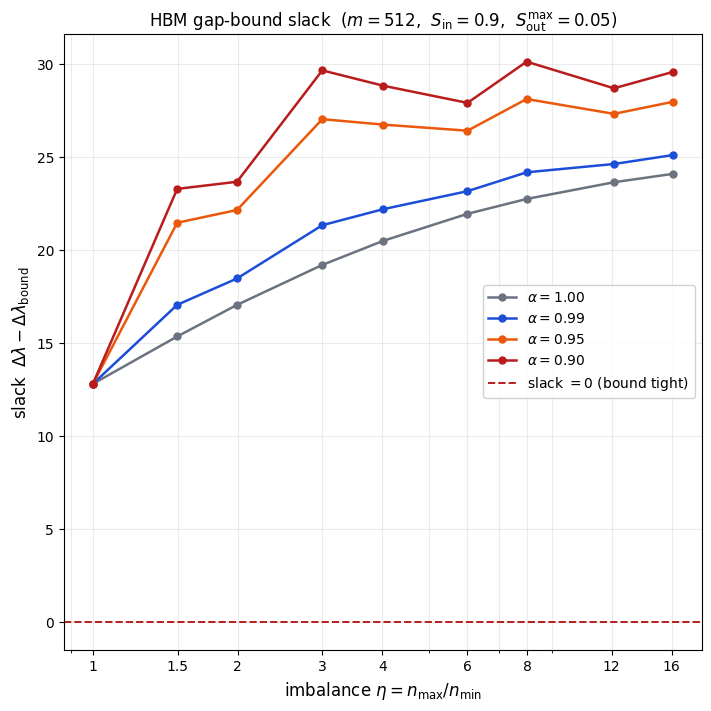

In [4]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)

for alpha in ALPHAS:
    r = records[alpha]
    ax.plot(r["eta"], r["slack"], "-o", ms=5, lw=1.8,
            color=ALPHA_COLORS[alpha], label=rf"$\alpha={alpha:.2f}$")

ax.axhline(0.0, color="#b91c1c", ls="--", lw=1.4, label="slack $=0$ (bound tight)")
ax.set_xscale("log")
ax.set_xticks(ETA_GRID)
ax.set_xticklabels([str(e) for e in ETA_GRID])
ax.set_xlabel(r"imbalance $\eta = n_{\max}/n_{\min}$", fontsize=12)
ax.set_ylabel(r"slack $\;\Delta\lambda - \Delta\lambda_{\rm bound}$", fontsize=12)
ax.set_title(rf"HBM gap-bound slack  ($m={M_SWEEP}$,  "
             rf"$S_{{\rm in}}={S_IN}$,  $S_{{\rm out}}^{{\max}}={S_OUT}$)",
             fontsize=12)
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=10, framealpha=0.9)
fig.savefig(OUT_DIR / "spectral_gap_bound.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 5 — Sanity table

The empirical gap, analytic bound, and slack for every $(\eta,\alpha)$. Note the
bound itself turns **negative** at large $\eta$ / small $\alpha$ (e.g.
$\alpha=0.90,\ \eta=16$): there Prop. `prop:D-gap` no longer guarantees a positive
gap, yet the slack stays $\ge 0$, confirming the inequality remains a valid lower
bound.

In [5]:
import pandas as pd

rows = []
for alpha in ALPHAS:
    r = records[alpha]
    for e, g, b, s in zip(r["eta"], r["gap"], r["bound"], r["slack"]):
        rows.append(dict(alpha=alpha, eta=round(e, 2),
                         gap=round(g, 1), bound=round(b, 1), slack=round(s, 1),
                         bound_positive=b > 0))
pd.DataFrame(rows)

,alpha,eta,gap,bound,slack,bound_positive
0,1.00,1.00,217.6,204.8,12.8,True
1,1.00,1.50,174.3,158.9,15.4,True
2,1.00,1.99,145.4,128.3,17.1,True
3,1.00,3.00,108.8,89.6,19.2,True
4,1.00,4.02,86.7,66.2,20.5,True
5,1.00,6.01,62.1,40.1,22.0,True
6,1.00,7.98,48.5,25.7,22.8,True
7,1.00,12.13,33.1,9.5,23.6,True
8,1.00,16.07,25.5,1.4,24.1,True
9,0.99,1.00,199.8,187.0,12.8,True
